In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
REVIEW_CAPACITY = 100
DATA_PATH = Path("../data/raw/creditcard.csv")

df = pd.read_csv(DATA_PATH)
df = df.sort_values("Time").reset_index(drop=True)

train_end = int(len(df) * 0.60)
validation_end = int(len(df) * 0.80)

train_df = df.iloc[:train_end].copy()
validation_df = df.iloc[train_end:validation_end].copy()
test_df = df.iloc[validation_end:].copy()

development_df = pd.concat(
    [train_df, validation_df],
    ignore_index=True,
)

FEATURES = [column for column in df.columns if column != "Class"]
TARGET = "Class"

X_development = development_df[FEATURES]
y_development = development_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(f"Development transactions: {len(development_df):,}")
print(f"Development fraud cases:  {y_development.sum():,}")
print(f"Test transactions:        {len(test_df):,}")
print(f"Test fraud cases:         {y_test.sum():,}")

Development transactions: 227,845
Development fraud cases:  417
Test transactions:        56,962
Test fraud cases:         75


## Final evaluation protocol

Logistic regression and a review capacity of 100 transactions were selected using
training and validation data. The model is now refitted using the combined development
period and evaluated once on the chronologically later test period.

The final model and operating policy will not be changed in response to the test
results.

In [2]:
scale_features = ["Time", "Amount"]
pca_features = [f"V{i}" for i in range(1, 29)]

preprocessor = ColumnTransformer(
    transformers=[
        ("scaled", RobustScaler(), scale_features),
        ("pca", "passthrough", pca_features),
    ]
)

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

final_model.fit(X_development, y_development)

test_scores = final_model.predict_proba(X_test)[:, 1]

print("Final model fitted.")

Final model fitted.


In [3]:
test_average_precision = average_precision_score(
    y_test,
    test_scores,
)

test_roc_auc = roc_auc_score(
    y_test,
    test_scores,
)

test_fraud_rate = y_test.mean()

print(f"Test fraud rate:        {test_fraud_rate:.4%}")
print(f"Test average precision: {test_average_precision:.4f}")
print(f"Test ROC-AUC:           {test_roc_auc:.4f}")

Test fraud rate:        0.1317%
Test average precision: 0.7622
Test ROC-AUC:           0.9863


In [4]:
ranked_indices = np.argsort(test_scores)[::-1]
review_indices = ranked_indices[:REVIEW_CAPACITY]

test_predictions = np.zeros(
    len(y_test),
    dtype=int,
)

test_predictions[review_indices] = 1

test_threshold = test_scores[review_indices[-1]]

print(f"Review capacity:       {REVIEW_CAPACITY}")
print(f"Test-period threshold: {test_threshold:.6f}")
print(f"Transactions flagged:  {test_predictions.sum()}")

Review capacity:       100
Test-period threshold: 0.990081
Transactions flagged:  100


In [5]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions,
).ravel()

test_precision = tp / (tp + fp)
test_recall = tp / (tp + fn)

print(f"True positives:  {tp:,}")
print(f"False positives: {fp:,}")
print(f"False negatives: {fn:,}")
print(f"True negatives:  {tn:,}")
print()
print(f"Alert precision: {test_precision:.2%}")
print(f"Fraud recall:    {test_recall:.2%}")

True positives:  59
False positives: 41
False negatives: 16
True negatives:  56,846

Alert precision: 59.00%
Fraud recall:    78.67%


In [6]:
test_cm = pd.DataFrame(
    [
        [tn, fp],
        [fn, tp],
    ],
    index=[
        "Actual legitimate",
        "Actual fraud",
    ],
    columns=[
        "Predicted legitimate",
        "Flagged for review",
    ],
)

test_cm

,Predicted legitimate,Flagged for review
Actual legitimate,56846,41
Actual fraud,16,59


In [7]:
def evaluate_capacity(y_true, scores, capacity):
    y_array = np.asarray(y_true)
    scores_array = np.asarray(scores)

    ranked = np.argsort(scores_array)[::-1]
    selected = ranked[:capacity]

    fraud_detected = y_array[selected].sum()
    total_fraud = y_array.sum()

    return {
        "review_capacity": capacity,
        "fraud_detected": int(fraud_detected),
        "false_alerts": int(capacity - fraud_detected),
        "precision": fraud_detected / capacity,
        "recall": fraud_detected / total_fraud,
        "alerts_per_1000": capacity / len(y_array) * 1000,
    }

In [8]:
test_capacity_results = pd.DataFrame(
    [
        evaluate_capacity(
            y_test,
            test_scores,
            capacity,
        )
        for capacity in [25, 50, 100, 250, 500, 1000]
    ]
)

test_capacity_results

,review_capacity,fraud_detected,false_alerts,precision,recall,alerts_per_1000
0,25,24,1,0.960,0.320000,0.438889
1,50,49,1,0.980,0.653333,0.877778
2,100,59,41,0.590,0.786667,1.755556
3,250,64,186,0.256,0.853333,4.388891
4,500,65,435,0.130,0.866667,8.777782
5,1000,67,933,0.067,0.893333,17.555563


In [9]:
test_capacity_display = test_capacity_results.copy()

test_capacity_display["precision"] = (
    test_capacity_display["precision"]
    .map("{:.2%}".format)
)

test_capacity_display["recall"] = (
    test_capacity_display["recall"]
    .map("{:.2%}".format)
)

test_capacity_display["alerts_per_1000"] = (
    test_capacity_display["alerts_per_1000"]
    .map("{:.2f}".format)
)

test_capacity_display

,review_capacity,fraud_detected,false_alerts,precision,recall,alerts_per_1000
0,25,24,1,96.00%,32.00%,0.44
1,50,49,1,98.00%,65.33%,0.88
2,100,59,41,59.00%,78.67%,1.76
3,250,64,186,25.60%,85.33%,4.39
4,500,65,435,13.00%,86.67%,8.78
5,1000,67,933,6.70%,89.33%,17.56


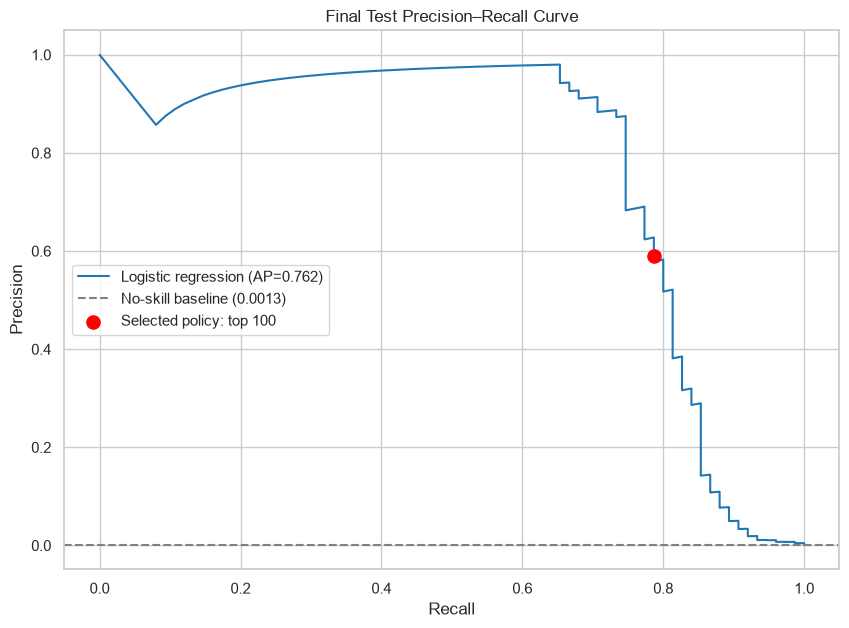

In [10]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    test_scores,
)

plt.figure(figsize=(10, 7))

plt.plot(
    recall,
    precision,
    color="tab:blue",
    label=(
        "Logistic regression "
        f"(AP={test_average_precision:.3f})"
    ),
)

plt.axhline(
    y=test_fraud_rate,
    color="gray",
    linestyle="--",
    label=f"No-skill baseline ({test_fraud_rate:.4f})",
)

plt.scatter(
    test_recall,
    test_precision,
    color="red",
    s=90,
    zorder=3,
    label=(
        f"Selected policy: top {REVIEW_CAPACITY}"
    ),
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Test Precision–Recall Curve")
plt.legend()
plt.show()

In [11]:
VALIDATION_AP = 0.0
VALIDATION_PRECISION_AT_100 = 0.45
VALIDATION_RECALL_AT_100 = 0.7895

In [12]:
validation_test_comparison = pd.DataFrame(
    [
        {
            "period": "Validation",
            "average_precision": VALIDATION_AP,
            "precision_at_100": (
                VALIDATION_PRECISION_AT_100
            ),
            "recall_at_100": (
                VALIDATION_RECALL_AT_100
            ),
        },
        {
            "period": "Test",
            "average_precision": (
                test_average_precision
            ),
            "precision_at_100": test_precision,
            "recall_at_100": test_recall,
        },
    ]
)

validation_test_comparison

,period,average_precision,precision_at_100,recall_at_100
0,Validation,0.000000,0.45,0.789500
1,Test,0.762239,0.59,0.786667


In [13]:
final_results = pd.DataFrame(
    [
        {
            "model": "Class-weighted logistic regression",
            "test_transactions": len(y_test),
            "test_fraud_cases": int(y_test.sum()),
            "average_precision": test_average_precision,
            "roc_auc": test_roc_auc,
            "review_capacity": REVIEW_CAPACITY,
            "fraud_detected": int(tp),
            "false_alerts": int(fp),
            "alert_precision": test_precision,
            "fraud_recall": test_recall,
        }
    ]
)

final_results

,model,test_transactions,test_fraud_cases,average_precision,roc_auc,review_capacity,fraud_detected,false_alerts,alert_precision,fraud_recall
0,Class-weighted logistic regression,56962,75,0.762239,0.986335,100,59,41,0.59,0.786667


In [14]:
final_results_display = final_results.copy()

for column in [
    "alert_precision",
    "fraud_recall",
]:
    final_results_display[column] = (
        final_results_display[column]
        .map("{:.2%}".format)
    )

for column in [
    "average_precision",
    "roc_auc",
]:
    final_results_display[column] = (
        final_results_display[column]
        .map("{:.4f}".format)
    )

final_results_display

,model,test_transactions,test_fraud_cases,average_precision,roc_auc,review_capacity,fraud_detected,false_alerts,alert_precision,fraud_recall
0,Class-weighted logistic regression,56962,75,0.7622,0.9863,100,59,41,59.00%,78.67%


## Final test results

The selected class-weighted logistic-regression model achieved a test average
precision of 0.7622 and ROC-AUC of 0.9863 on the chronologically later test period.

Under the preselected policy of reviewing the 100 highest-risk transactions, the
model detected 59 of 75 fraud cases. This produced 59.00% alert precision and
78.67% fraud recall, with 41 legitimate transactions sent for review.

Operational performance was similar to validation performance. Fraud recall remained
nearly unchanged, decreasing slightly from 78.95% to 78.67%, while alert precision
increased from 45.00% to 59.00%. The higher precision partly reflects the greater
number of fraud cases in the test period. These results illustrate the importance
of chronological testing: fraud patterns and class prevalence can vary over time,
even within a dataset covering only approximately two days.

The model should be interpreted as an alert-prioritization system rather than an
automated fraud-decision system. Its output ranks transactions for human review,
and the appropriate review capacity depends on investigation resources, fraud
losses and the cost of unnecessary interventions.

## Limitations

- The dataset contains transactions from only two days and cannot demonstrate
  long-term concept drift.
- V1–V28 are anonymous PCA components, limiting business-level interpretation and
  feature engineering.
- No customer, merchant, device, geographic or transaction-network identifiers are
  available.
- The dataset reflects confirmed labels, which may omit undetected fraud.
- The review capacity of 100 is illustrative rather than derived from actual staffing
  or fraud-loss data.
- Bootstrap intervals from the preceding analysis condition on the fitted models and
  do not capture every source of training uncertainty.
- Production deployment would require monitoring, retraining, probability calibration,
  fairness review and controls governing investigator actions.